# Pandas for Astronomy: Exploring Near-Earth Object (NEO) Comets

In this workshop we will use **pandas** to explore a real NASA dataset of near-Earth comets. Along the way you will practice every essential pandas skill and see how each one connects to real astronomical questions.

## pandas 101

- Pandas is one of the most commonly used Python packages/libraries/modules for data science.<br>
- Pandas is Python's answer for making two dimensional tables (aka **PAN**el **DA**ta).<br>
- Pandas calls a table a "DataFrame".<br>
- Pandas DataFrames are used by Python's other packages for statistical analysis, data manipulation, and data visualization.<br>
- Pandas DataFrames can be exported as .csv and other files.<br>

### Workshop sections
1. Loading and inspecting the data
2. Selecting rows and columns
3. Filtering with boolean indexing
4. Sorting and ranking
5. Computing new columns and `.apply()`
6. Handling missing data
7. Groupby and aggregation
8. Working with dates and times
9. Basic visualization
10. Saving your results

# 1. Loading and Inspecting the Data

First, import pandas. The convention is to alias it as `pd` to save typing.


In [ ]:
import pandas as pd
import numpy as np

pd.__version__

## 1.1 Reading the CSV file

We load the comet data with `pd.read_csv()`. This returns a **DataFrame** object. You can open the file, define it as a Pandas DataFrame, assign it to a variable, and close the file in one line. (Already we're seeing the differences from basic Python).


In [ ]:
# If using Google Colab, first run:
# !wget https://raw.githubusercontent.com/nuitrcs/python_workshops_datarepo/refs/heads/main/NEOcomets.csv

df = pd.read_csv("NEOcomets.csv")
df # view the dataframe by printing to the console

Take a minute to look at the data. 
<br><br>The number at the beginning of each row is called an **index**. The index was automatically assigned by pandas when the dataset was loaded. It was not in the original csv file. It is merely a series of consecutive numbers going down the rows. The rows were loaded in whatever order they were in the csv file.

### What is this dataset?

The file `NEOcomets.csv` comes from NASA's Jet Propulsion Laboratory (JPL) Small-Body Database. It lists **208 near-Earth comets** with key physical and orbital parameters:

| Column | Meaning |
|---|---|
| `spkid` | Unique JPL identifier |
| `full_name` | Comet designation and name |
| `sats` | Number of known satellites |
| `diameter` | Nucleus diameter (km) |
| `class` | Dynamical class (JFc/JFC, HTC, ETc) |
| `data_arc` | Length of observational data arc (days) |
| `first_obs` / `last_obs` | Dates of first and last observation |
| `e` | Orbital eccentricity (0=circle, <1=ellipse) |
| `a` | Semi-major axis (AU) |
| `i` | Orbital inclination (degrees) |
| `per_y` | Orbital period (years) |
| `condition_code` | Orbit quality: 0 (best) to 9 (worst) |

**Comet classes:**
- **JFc / JFC** — Jupiter-family comets: short-period, low-inclination
- **HTC** — Halley-type comets: longer periods, often retrograde
- **ETc** — Encke-type comets: very short period (<3.3 years)

## 1.2 Quick overview methods


In [ ]:
df.head()   # first 5 rows

In [ ]:
df.tail(3)  # last 3 rows

In [ ]:
df.sample(5)  # 5 random rows

In [ ]:
df.shape    # (rows, columns)

In [ ]:
df.columns # list of column names

In [ ]:
df.dtypes   # data type of each column

In [ ]:
df.info()   # compact summary

In [ ]:
df.describe()  # summary statistics

### Renaming columns

We can use the `rename()` method. We need to pass the function a **dictionary** of the old name to be replaced as the key and the new name as the value.

In [ ]:
df.rename(columns = {
    # old-key : new-value
    'spkid' : 'cometID',
    'sats'  : 'n_satellites',
    'e' : 'eccentricity',
    'a' : 'axis',
    'i' : 'inclination',
    'per_y' : 'period_years'
})

In [ ]:
df.columns

<br><br>It didn't change! DataFrames are **immutable objects** like strings and numpy arrays. To save the renamed DataFrame, we would have to reassign it to a variable:

In [ ]:
df_new = df.rename(columns = {
    # old-key : new-value
    'spkid' : 'cometID',
    'sats'  : 'n_satellites',
    'per_y' : 'period_years'
})

df_new.head(5)

### Exercise 1

1. How many rows and columns does the dataset have?
2. Which columns contain string (object) data?
3. Use `.sample()` to display 8 random rows.
4. Write code to rename the columns a, i, e to be more informative


In [ ]:
# Your code here


# 2. Selecting Rows and Columns


## 2.1 Selecting a single column

Use `df["column_name"]` to select one column. This returns a **Series**.


In [ ]:
df["full_name"]

In [ ]:
type(df["full_name"])

A pandas Series is a one-dimensional labeled array — essentially a single column (or row) of data with an index attached to each value.
You can think of it like a Python list, but with two key additions:

* An index — each value has a label (by default, integers starting at 0, but can be anything)
* A single data type — all values in a Series are the same type (int, float, string, etc.) <br>
Under the hood, a DataFrame is essentially a dict of Series objects, all sharing the same index. You can even see this by calling df.to_dict(), which converts it back to a dictionary object.

## 2.2 Selecting multiple columns

Pass a **list** of column names. This returns a DataFrame.


In [ ]:
df[["full_name", "class", "per_y", "e", "i"]]

## 2.3 Selecting rows with `.iloc[]` and `.loc[]`

- **`.iloc[]`** selects by integer position
- **`.loc[]`** selects by index label


In [ ]:
df.iloc[0]         # first row by position

In [ ]:
df.iloc[0:5]       # rows 0-4

In [ ]:
df.iloc[0,10]    # row 0, col 10

In [ ]:
df.iloc[2:5, 3:10]  # rows 2-5, cols 3-10

In [ ]:
df.loc[0:4, ["full_name", "class", "per_y"]]  # rows 0-4, specific columns

### Exercise 2

1. Select `full_name`, `e`, `a`, and `per_y` for the first 10 rows.
2. Use `.iloc[]` to retrieve the last row.
3. Use `.loc[]` to retrieve rows 50-54 and columns `full_name`, `class`, `diameter`.


In [ ]:
# Your code here


## 2.4 Dropping rows and columns

Let's drop a single row from the DataFrame. How about row 2? You still have to assign `df` to a variable to make the change permanent:

In [ ]:
df.head(5)

In [ ]:
df = df.drop(2)
df.head(5)

<br>The index numbers did not reset when we dropped a row. 2 is missing!

We can reset the index and pretend like 2 was never there. The `reset_index()` function takes one keyword argument. If we don't pass the argument, `drop=True`, an extra column will get added to our DataFrame containing the old index numbers. Let's first reset the index without passing the argument, but we won't save that DataFrame:

In [ ]:
df.reset_index()

You can see that new column `index` contains the original index positions. Now let's save a new version of our DataFrame, with the indexes reset, but without that new column:

In [ ]:
df = df.reset_index(drop=True)

In [ ]:
df.head()

<br><br><br>The `drop()` function defaults to dropping rows. If we want to drop a column, we need to add one more argument. `axis=1` is used in pandas to refer to columns as opposed to rows (`axis=0`). The `axis` argument is used elsewhere in pandas, too. Let's drop the "X" column:

In [ ]:
df = df.drop("condition_code", axis=1)

In [ ]:
df.head()

## 2.5 Sorting a DataFrame

If you want to sort by the index numbers, or if you want to sort by the column names (alphabetically), you use `sort_index`. It can take two arguments: the axis to sort by (row or column) and the order (ascending or not):

The default arguments are to sort by row index with 0 at the top, which is how we've already been viewing the data:

In [ ]:
df.sort_index()

Let's try more arguments:

In [ ]:
df.sort_index(ascending=False)

In [ ]:
df.sort_index(axis=1)

In [ ]:
df.sort_index(axis=1, ascending=False)

<br><br><br>The second sort function, `sort_values()`, will sort the frame by the data in a column:

In [ ]:
df.sort_values("per_y")

In [ ]:
df.sort_values("first_obs")

### Exercise 2.2

Write code to sort the DataFrame by the diameter, with the largest values at the top:

In [ ]:
# your code here

# 3. Filtering with Boolean Indexing

Create a True/False Series and use it to select matching rows.


## 3.1 Single condition


In [ ]:
# Which comets are Halley-type (HTC)?
df[df["class"] == "HTC"]

In [ ]:
# Comets with periods longer than 20 years
df[df["per_y"] > 20]

In [ ]:
# Comets with near-parabolic orbits: eccentricity > 0.95
df[df["e"] > 0.95]

## 3.2 Multiple conditions

Use `&` (and) and `|` (or). **Always wrap each condition in parentheses.**


In [ ]:
# Jupiter-family comets with periods under 10 years
mask = (df["class"].isin(["JFc", "JFC"])) & (df["per_y"] < 10)
df[mask]

In [ ]:
# Retrograde comets: inclination > 90 degrees means the comet
# orbits in the OPPOSITE direction to the planets!
retrograde = df[df["i"] > 90]
print(f"{len(retrograde)} retrograde comets:")
retrograde[["full_name", "class", "i", "per_y"]]

In [ ]:
# Find Halley's comet by name using .str.contains()
df[df["full_name"].str.contains("Halley")]

### Exercise 3

1. Filter to show comets with diameter > 5 km.
2. Find HTC comets with a known diameter (not NaN).
3. Find comets with `condition_code == 0` (best orbits). How many?
4. **Challenge:** Filter for comets with eccentricity below 0.65.


In [ ]:
# Your code here


# 4. Sorting and Ranking


## 4.1 Sorting by a single column


In [ ]:
# Largest comets by diameter
df.sort_values("diameter", ascending=False).head(10)[["full_name", "diameter", "class", "per_y"]]

In [ ]:
# Longest orbital periods
df.sort_values("per_y", ascending=False).head(10)[["full_name", "class", "per_y", "a"]]

## 4.2 Sorting by multiple columns


In [ ]:
# Sort by class, then by period within each class
df.sort_values(["class", "per_y"])[["full_name", "class", "per_y"]].head(15)

## 4.3 Ranking


In [ ]:
df_sorted = df.copy()
df_sorted["period_rank"] = df_sorted["per_y"].rank(ascending=False)
df_sorted[["full_name", "per_y", "period_rank"]].sort_values("period_rank").head(10)

### Exercise 4

1. Sort by eccentricity (`e`) from highest to lowest. Show the top 5.
2. Sort by `class` then by `e` descending within each class.


In [ ]:
# Your code here


# 5. Computing New Columns

Pandas applies arithmetic column-wide automatically — no loops needed.


## 5.1 Verifying Kepler's Third Law

**Kepler's Third Law**: $T^2 = a^3$ (when $T$ is in years and $a$ is in AU).

Let's check whether this holds for real comet data!


In [ ]:
# T^2 / a^3 should be very close to 1.0 for all comets
df["kepler_ratio"] = df["per_y"]**2 / df["a"]**3
df[["full_name", "per_y", "a", "kepler_ratio"]].head(10)

In [ ]:
# Mean should be ≈ 1.0
df["kepler_ratio"].describe()

## 5.2 Converting units

1 AU = 149,597,870 km ≈ 8.317 light-minutes


In [ ]:
AU_TO_KM = 149_597_870
AU_TO_LIGHTMIN = 8.317

df["a_km"] = df["a"] * AU_TO_KM
df["a_lightmin"] = df["a"] * AU_TO_LIGHTMIN

df[["full_name", "a", "a_km", "a_lightmin"]].head(8)

## 5.3 Using `.apply()` with a custom function

`.apply()` runs a Python function element-by-element on a column.


In [ ]:
def classify_period(period_years):
    """Classify a comet by its orbital period."""
    if period_years < 3.3:
        return "Very short-period (<3.3 yr)"
    elif period_years < 20:
        return "Short-period (3.3-20 yr)"
    elif period_years < 200:
        return "Intermediate (20-200 yr)"
    else:
        return "Long-period (>200 yr)"

df["period_class"] = df["per_y"].apply(classify_period)
df[["full_name", "per_y", "period_class"]].sample(10)

In [ ]:
# Alterative method with pd.cut
df["period_class_cut"] = pd.cut(
    df["per_y"],
    bins=[0, 3.3, 20, 200, float("inf")],
    labels=["Very short-period (<3.3 yr)", 
            "Short-period (3.3-20 yr)",
            "Intermediate (20-200 yr)", 
            "Long-period (>200 yr)"]
)

df[["full_name", "per_y", "period_class", "period_class_cut"]].sample(10)

## 5.4 `np.where()` for binary classification


In [ ]:
# Flag retrograde comets (inclination > 90 degrees)
df["retrograde"] = np.where(df["i"] > 90, "Retrograde", "Prograde")
df[["full_name", "i", "retrograde"]].head(10)

### Exercise 5

1. Create `period_days` converting `per_y` to days (use 365.25 days/year).
2. Create `high_quality` that is `True` when `condition_code == 0`.
3. **Challenge:** Write `orbit_shape(e)` returning "Nearly circular" (e<0.3), "Moderate ellipse" (0.3-0.8), or "Highly elliptical" (e>0.8). Apply it to make a column.


In [ ]:
# Your code here


## 5.5 Aggregating across the whole dataframe and across columns
If you use a method function on the entire dataset, it will try its best to execute the method for all columns.

#### How many values are in each column?

In [220]:
df.count()

spkid               207
full_name           207
sats                207
diameter             19
class               207
data_arc            203
first_obs           206
last_obs            206
e                   207
a                   207
i                   207
per_y               207
period_class        207
period_class_cut    207
retrograde          207
obs_span_days       206
first_obs_year      206
first_obs_month     206
century             206
dtype: int64

#### What is the smallest value in each column?

In [ ]:
df.min()

#### What is the sum of all values in each column?

In [ ]:
df.sum()

#### What are the unique values in each column?

In [221]:
df.unique()

AttributeError: 'DataFrame' object has no attribute 'unique'

<br>**Uh-oh.** Not all functions will work on the entire DataFrame. 
<br>Most of the time you are interested in only a subset of the data. You can aggregate the data in a single column:

#### <br>The `unique()` method function provides all unique values in a column, as a pandas object:

In [227]:
df["per_y"].unique()

array([ 75.9 ,   3.31,   5.46,   6.32,  13.6 ,  71.2 ,  68.1 ,   6.52,
         6.72,  61.9 ,   6.55,  70.5 ,   8.17,   5.26,  27.4 ,  11.  ,
       155.  ,   5.42,   5.44,  33.2 ,  14.8 ,   6.44,   9.06,   5.37,
         5.36,   5.31,   5.4 ,   5.33,   5.51,   5.38,   6.09,   5.35,
         5.2 ,   5.49,   6.08,   5.39,   5.04,   5.41,   5.45,   4.96,
         4.65,   5.53,   5.29,   5.58,   5.43,   5.57,   4.38,   4.69,
         4.31,   5.09,   5.11,   5.55,   5.14,   5.17,   5.3 ,   5.32,
         5.34,   5.16,   5.5 ,   4.91,   9.55,   5.54,   5.28,   5.21,
         5.15,  11.8 ,   6.48,   5.74, 133.  ,  74.3 ,   5.22,   6.18,
        21.5 ,   4.21, 120.  ,   7.52,   5.02,   4.98,   4.86,   5.81,
         7.62,   5.07,   5.62,   7.85,   4.83,   4.61,  18.3 , 188.  ,
         5.73,   4.43,   5.47,   5.08,   6.75,   3.78,   3.99,   4.15,
         4.22,   6.29,   8.67,   4.88,   4.95,  10.5 ,   6.85,   4.67,
         5.25,   5.13,  13.3 ,   5.24,   3.34,   4.35,   5.6 ,   7.2 ,
      

This can easily be turned into a list:

In [228]:
list(df["per_y"].unique())

[75.9,
 3.31,
 5.46,
 6.32,
 13.6,
 71.2,
 68.1,
 6.52,
 6.72,
 61.9,
 6.55,
 70.5,
 8.17,
 5.26,
 27.4,
 11.0,
 155.0,
 5.42,
 5.44,
 33.2,
 14.8,
 6.44,
 9.06,
 5.37,
 5.36,
 5.31,
 5.4,
 5.33,
 5.51,
 5.38,
 6.09,
 5.35,
 5.2,
 5.49,
 6.08,
 5.39,
 5.04,
 5.41,
 5.45,
 4.96,
 4.65,
 5.53,
 5.29,
 5.58,
 5.43,
 5.57,
 4.38,
 4.69,
 4.31,
 5.09,
 5.11,
 5.55,
 5.14,
 5.17,
 5.3,
 5.32,
 5.34,
 5.16,
 5.5,
 4.91,
 9.55,
 5.54,
 5.28,
 5.21,
 5.15,
 11.8,
 6.48,
 5.74,
 133.0,
 74.3,
 5.22,
 6.18,
 21.5,
 4.21,
 120.0,
 7.52,
 5.02,
 4.98,
 4.86,
 5.81,
 7.62,
 5.07,
 5.62,
 7.85,
 4.83,
 4.61,
 18.3,
 188.0,
 5.73,
 4.43,
 5.47,
 5.08,
 6.75,
 3.78,
 3.99,
 4.15,
 4.22,
 6.29,
 8.67,
 4.88,
 4.95,
 10.5,
 6.85,
 4.67,
 5.25,
 5.13,
 13.3,
 5.24,
 3.34,
 4.35,
 5.6,
 7.2,
 114.0,
 18.7,
 143.0,
 70.7,
 181.0,
 73.9,
 58.2,
 5.97,
 84.1,
 51.3,
 6.62,
 48.5,
 5.77,
 5.79,
 4.12,
 28.5,
 21.9,
 23.7,
 65.8,
 24.8,
 20.5,
 11.1,
 61.3,
 86.4,
 31.0,
 108.0,
 6.84,
 139.0,
 1.03,
 1.64,
 8.

#### The `nunique()` method tells you how many unique values are present in a column:

In [229]:
df["per_y"].nunique()

148

In [232]:
df["per_y"].unique().shape # same as nunique, but not a directly usable value

(148,)

# 6. Handling Missing Data

Real astronomical datasets almost always have gaps. Only 19 of 208 comets have a measured diameter, and some lost comets have no observations at all.


## 6.1 Finding missing values


In [ ]:
# Count NaNs per column
df.isnull().sum()

In [ ]:
# As a percentage
(df.isnull().sum() / len(df) * 100).round(1).astype(str) + "%"

In [ ]:
# Which comets are missing a diameter?
df[df["diameter"].isnull()][["full_name", "class", "per_y"]].head(10)

## 6.2 Dropping rows with missing values


In [ ]:
# Keep only comets with a known diameter
df_with_diameter = df[df["diameter"].notnull()]
print(f"{len(df_with_diameter)} comets have a known diameter.")
df_with_diameter[["full_name", "diameter", "class"]].sort_values("diameter", ascending=False)

## 6.3 Filling missing values


In [ ]:
median_diam = df["diameter"].median()
print(f"Median diameter: {median_diam} km")

df_filled = df.copy()
df_filled["diameter"] = df_filled["diameter"].fillna(median_diam)
print("Remaining NaNs:", df_filled["diameter"].isnull().sum())

> **Research note:** Filling with the median is convenient, but may not be scientifically appropriate. For comet diameters specifically, the size distribution is highly skewed and small/faint comets are observationally biased. Always justify imputation choices in real analyses.


### Exercise 6

1. How many comets are missing *both* `first_obs` and `last_obs`? These are likely lost or disintegrated comets.
2. Create a DataFrame with only comets that have known `first_obs`, `last_obs`, *and* `diameter`.
3. Why might filling missing `condition_code` values with the mean be problematic?


In [ ]:
# Your code here


# 7. Groupby and Aggregation

`groupby()` splits the data into groups, applies a function, and combines results.


## 7.1 Basic groupby


In [ ]:
# Average orbital period by comet class


In [ ]:
# Count of comets in each class
df.groupby("class").size().rename("count")

## 7.2 Multiple aggregations


In [ ]:
# Multiple stats at once with .agg()
df.groupby("class")[["per_y", "e", "i"]].agg(["mean", "median", "std"]).round(2)

## 7.3 Groupby with a custom column


In [ ]:
# Average eccentricity by period classification
df.groupby("period_class")["e"].agg(["mean", "count"]).round(3)

In [ ]:
# Retrograde vs prograde orbital properties
df.groupby("retrograde")[["per_y", "e", "i"]].mean().round(2)

### Exercise 7

1. What is the maximum known diameter within each comet class?
2. Mean and std of eccentricity grouped by `retrograde` status.
3. **Challenge:** What fraction of comets in each `period_class` are retrograde? *Hint: create a boolean `is_retrograde` column, then use `.mean()` after groupby.*


In [ ]:
# Your code here


# 8. Working with Dates and Times

Astronomy is deeply time-based. The `first_obs` and `last_obs` columns are currently strings — we need to convert them to datetime objects for date arithmetic.


In [204]:
df[['spkid', 'full_name', 'sats', 'diameter', 'class', 'data_arc', 'first_obs', 'last_obs']]

,spkid,full_name,sats,diameter,class,data_arc,first_obs,last_obs
0,1000036,1P/Halley,0,11.0,HTC,57852.0,1835-08-21,1994-01-11
1,1000025,2P/Encke,0,4.8,ETc,2546.0,2018-11-05,2025-10-25
2,1000505,5D/Brorsen,0,NaN,JFc,NaN,NaN,NaN
3,1000069,7P/Pons-Winnecke,0,5.2,JFc,38253.0,1921-04-28,2026-01-20
4,1000099,8P/Tuttle,0,4.5,JFC,20161.0,1967-01-07,2022-03-20
...,...,...,...,...,...,...,...,...
202,1003909,P/2021 PE20 (ATLAS),0,NaN,JFc,95.0,2021-08-09,2021-11-12
203,1003804,P/2021 Q5 (ATLAS),0,NaN,JFc,77.0,2021-08-29,2021-11-14
204,1003914,C/2023 E1 (ATLAS),0,NaN,HTC,325.0,2022-12-25,2023-11-15
205,1003954,C/2023 S3 (Lemmon),0,NaN,HTC,251.0,2023-09-25,2024-06-02


## 8.1 Parsing dates


In [205]:
# Current dtypes -- both are string (object)
print(df[["first_obs", "last_obs"]].dtypes)

first_obs    str
last_obs     str
dtype: object


In [206]:
# Convert to datetime
pd.to_datetime(df["first_obs"])

ValueError: time data "1927-??-??" doesn't match format "%Y-%m-%d". You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

What might be the reason for this error?

You could solve this by replacing all `??` values with a placeholder like 01 to denote first month or first day.

In [207]:
# replace the ?? with better placeholders
df["first_obs"] = df["first_obs"].str.replace("-??", "-01", regex=False)
df["last_obs"] = df["last_obs"].str.replace("-??", "-01", regex=False)

In [208]:
# now convert to datetime series
df["first_obs"] = pd.to_datetime(df["first_obs"], errors="coerce")
df["last_obs"]  = pd.to_datetime(df["last_obs"],  errors="coerce")

In [209]:
df[["full_name", "first_obs", "last_obs"]].head(10)

,full_name,first_obs,last_obs
0,1P/Halley,1835-08-21,1994-01-11
1,2P/Encke,2018-11-05,2025-10-25
2,5D/Brorsen,NaT,NaT
3,7P/Pons-Winnecke,1921-04-28,2026-01-20
4,8P/Tuttle,1967-01-07,2022-03-20
5,12P/Pons-Brooks,1953-06-20,2025-06-07
6,13P/Olbers,1887-08-27,2025-07-31
7,15P/Finlay,2008-04-27,2022-03-03
8,18D/Perrine-Mrkos,1961-11-29,1968-12-26
9,20D/Westphal,1852-09-01,1913-10-13


Notice the `NaT` values - what might they denote?

To drop missing values, you could use the `dropna` function

In [210]:
df[["full_name", "first_obs", "last_obs"]].dropna().head(10)

,full_name,first_obs,last_obs
0,1P/Halley,1835-08-21,1994-01-11
1,2P/Encke,2018-11-05,2025-10-25
3,7P/Pons-Winnecke,1921-04-28,2026-01-20
4,8P/Tuttle,1967-01-07,2022-03-20
5,12P/Pons-Brooks,1953-06-20,2025-06-07
6,13P/Olbers,1887-08-27,2025-07-31
7,15P/Finlay,2008-04-27,2022-03-03
8,18D/Perrine-Mrkos,1961-11-29,1968-12-26
9,20D/Westphal,1852-09-01,1913-10-13
10,21P/Giacobini-Zinner,2011-05-01,2024-10-21


## 8.2 Date arithmetic


In [211]:
# Compute the observation arc in days from the actual dates
# The dataset also has a data_arc column -- let's verify they agree!
df["obs_span_days"] = (df["last_obs"] - df["first_obs"]).dt.days

df[["full_name", "first_obs", "last_obs", "data_arc", "obs_span_days"]].dropna().head(10)

,full_name,first_obs,last_obs,data_arc,obs_span_days
0,1P/Halley,1835-08-21,1994-01-11,57852.0,57852.0
1,2P/Encke,2018-11-05,2025-10-25,2546.0,2546.0
3,7P/Pons-Winnecke,1921-04-28,2026-01-20,38253.0,38253.0
4,8P/Tuttle,1967-01-07,2022-03-20,20161.0,20161.0
5,12P/Pons-Brooks,1953-06-20,2025-06-07,26285.0,26285.0
6,13P/Olbers,1887-08-27,2025-07-31,50377.0,50377.0
7,15P/Finlay,2008-04-27,2022-03-03,5058.0,5058.0
8,18D/Perrine-Mrkos,1961-11-29,1968-12-26,2584.0,2584.0
9,20D/Westphal,1852-09-01,1913-10-13,22321.0,22321.0
10,21P/Giacobini-Zinner,2011-05-01,2024-10-21,4922.0,4922.0


In [212]:
# Which comet has the longest observational history?
df[["full_name", "first_obs", "last_obs", "obs_span_days"]].dropna().sort_values("obs_span_days", ascending=False).head(5)

,full_name,first_obs,last_obs,obs_span_days
105,109P/Swift-Tuttle,1737-07-08,1995-03-29,94131.0
134,273P/Pons-Gambart,1827-06-21,2014-04-04,68223.0
0,1P/Halley,1835-08-21,1994-01-11,57852.0
16,35P/Herschel-Rigollet,1788-01-01,1940-01-01,55516.0
106,122P/de Vico,1846-03-02,1996-06-25,54902.0


## 8.3 Extracting date components with `.dt`


In [213]:
# Extract year and month from first_obs
df["first_obs_year"]  = df["first_obs"].dt.year
df["first_obs_month"] = df["first_obs"].dt.month

df[["full_name", "first_obs", "first_obs_year", "first_obs_month"]].dropna().head(10)

,full_name,first_obs,first_obs_year,first_obs_month
0,1P/Halley,1835-08-21,1835.0,8.0
1,2P/Encke,2018-11-05,2018.0,11.0
3,7P/Pons-Winnecke,1921-04-28,1921.0,4.0
4,8P/Tuttle,1967-01-07,1967.0,1.0
5,12P/Pons-Brooks,1953-06-20,1953.0,6.0
6,13P/Olbers,1887-08-27,1887.0,8.0
7,15P/Finlay,2008-04-27,2008.0,4.0
8,18D/Perrine-Mrkos,1961-11-29,1961.0,11.0
9,20D/Westphal,1852-09-01,1852.0,9.0
10,21P/Giacobini-Zinner,2011-05-01,2011.0,5.0


In [214]:
# Comets first observed in each century
df["century"] = (df["first_obs_year"] // 100) * 100
df.dropna(subset=["century"]).groupby("century").size().rename("comets_first_observed")

century
1700.0      4
1800.0     11
1900.0     38
2000.0    153
Name: comets_first_observed, dtype: int64

In [215]:
# Which month sees the most first observations?
month_counts = df["first_obs_month"].value_counts().sort_index()
month_counts

first_obs_month
1.0      8
2.0     10
3.0     27
4.0     55
5.0     12
6.0     10
7.0     15
8.0     17
9.0      9
10.0    12
11.0    13
12.0    18
Name: count, dtype: int64

## 8.4 Filtering by date


In [216]:
# Comets first discovered in or after 2000
modern = df[df["first_obs_year"] >= 2000]
print(f"{len(modern)} comets first observed in 2000 or later")
modern[["full_name", "first_obs", "class"]].head(10)

153 comets first observed in 2000 or later


,full_name,first_obs,class
1,2P/Encke,2018-11-05,ETc
7,15P/Finlay,2008-04-27,JFc
10,21P/Giacobini-Zinner,2011-05-01,JFc
12,24P/Schaumasse,2000-10-07,JFc
13,26P/Grigg-Skjellerup,2007-12-19,JFc
17,41P/Tuttle-Giacobini-Kresak,2016-11-10,JFc
18,45P/Honda-Mrkos-Pajdusakova,2016-11-05,JFc
19,46P/Wirtanen,2013-10-30,JFc
22,67P/Churyumov-Gerasimenko,2008-06-01,JFc
24,73P/Schwassmann-Wachmann 3,2016-02-13,JFc


### Exercise 8

1. List comets first observed before 1900 by name and year.
2. Compute `obs_span_years` by dividing `obs_span_days` by 365.25.
3. **Challenge:** Does the computed `obs_span_days` match `data_arc` for all comets? Find any rows where they differ by more than 30 days.


In [ ]:
# Your code here


# 9. Basic Visualization

Pandas has built-in plotting powered by matplotlib.


In [217]:
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-whitegrid")

## 9.1 Histogram: orbital period distribution


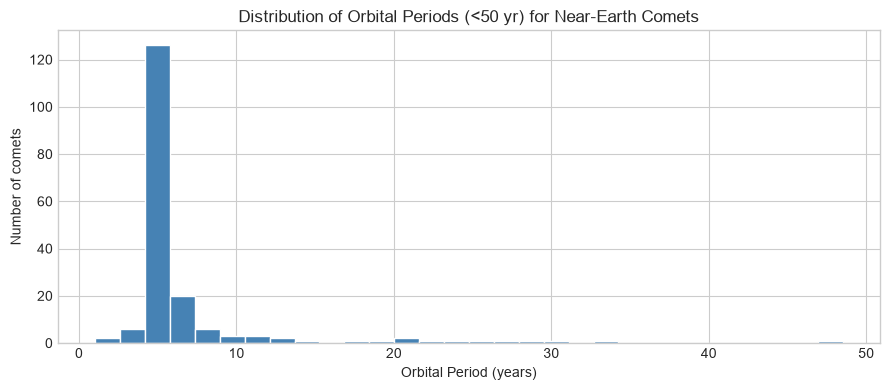

In [218]:
fig, ax = plt.subplots(figsize=(9, 4))
df[df["per_y"] < 50]["per_y"].plot.hist(bins=30, ax=ax, color="steelblue", edgecolor="white")
ax.set_xlabel("Orbital Period (years)")
ax.set_ylabel("Number of comets")
ax.set_title("Distribution of Orbital Periods (<50 yr) for Near-Earth Comets")
plt.tight_layout()
plt.show()

## 9.2 Scatter plot: eccentricity vs inclination


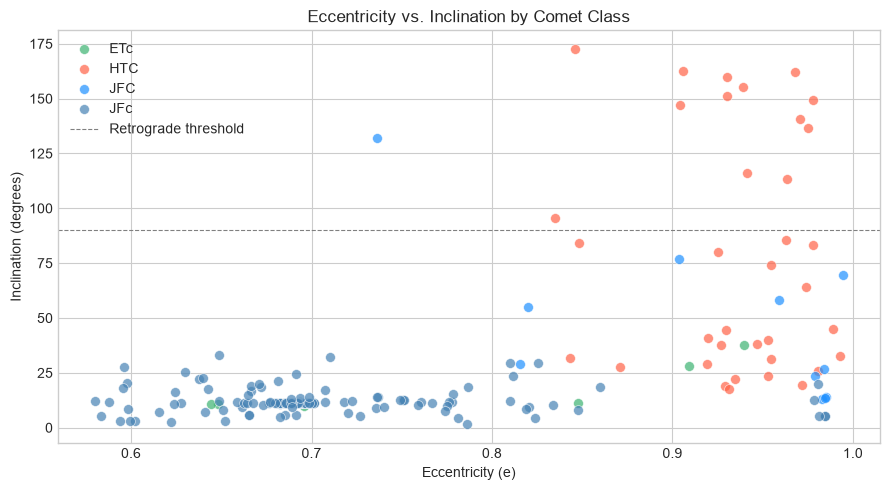

In [219]:
class_colors = {"JFc": "steelblue", "JFC": "dodgerblue", "HTC": "tomato", "ETc": "mediumseagreen"}

fig, ax = plt.subplots(figsize=(9, 5))
for cls, group in df.groupby("class"):
    ax.scatter(group["e"], group["i"],
               label=cls, color=class_colors.get(cls, "gray"),
               alpha=0.7, s=50, edgecolors="white", linewidths=0.5)

ax.axhline(90, color="gray", linestyle="--", linewidth=0.8, label="Retrograde threshold")
ax.set_xlabel("Eccentricity (e)")
ax.set_ylabel("Inclination (degrees)")
ax.set_title("Eccentricity vs. Inclination by Comet Class")
ax.legend()
plt.tight_layout()
plt.show()

# Notice: JFc comets cluster at low inclination (near the ecliptic plane).
# HTC comets are spread across all inclinations, including retrograde!

## 9.3 Bar chart: comet counts by class


In [ ]:
class_counts = df["class"].value_counts()

fig, ax = plt.subplots(figsize=(7, 4))
class_counts.plot.bar(ax=ax,
                      color=[class_colors.get(c, "gray") for c in class_counts.index],
                      edgecolor="white")
ax.set_xlabel("Comet Class")
ax.set_ylabel("Count")
ax.set_title("Near-Earth Comets by Dynamical Class")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

## 9.4 Line chart: comet discoveries over time


In [ ]:
yearly = df.dropna(subset=["first_obs_year"]).groupby("first_obs_year").size().rename("new_comets")

fig, ax = plt.subplots(figsize=(10, 4))
yearly.plot(ax=ax, color="steelblue")
ax.set_xlabel("Year")
ax.set_ylabel("Comets first observed")
ax.set_title("Comet First-Observation Dates Over Time\n(spikes often reflect dedicated survey programs)")
plt.tight_layout()
plt.show()

### Exercise 9

1. Histogram of inclination (`i`) with 20 bins. Add a vertical red line at 90 degrees.
2. Scatter plot of `a` (x) vs `per_y` (y) for comets with `per_y < 100`. Can you see Kepler's Third Law?
3. **Challenge:** Redo the scatter with `a**1.5` on the x-axis. What does the relationship look like now?


In [ ]:
# Your code here


# 10. Saving Your Results


In [ ]:
# Save the full enriched DataFrame
df.to_csv("NEOcomets_enriched.csv", index=False)
print("Saved NEOcomets_enriched.csv")

In [ ]:
# Save a filtered subset
df_known_diam = df[df["diameter"].notnull()]
df_known_diam.to_csv("NEOcomets_with_diameter.csv", index=False)
print(f"Saved {len(df_known_diam)} comets with known diameters.")

In [ ]:
# Save a summary table
summary = df.groupby("class")[["per_y", "e", "i"]].mean().round(3)
summary.to_csv("comet_class_summary.csv")
summary

# Bonus: Putting It All Together

A complete mini-analysis pipeline combining everything from this workshop.


In [236]:
# Full analysis pipeline

# Step 1: Load
comets = pd.read_csv("NEOcomets.csv")

# Step 2: Parse dates -- remember to replace ?? with 01 to handle partial missingness
comets["first_obs"] = comets["first_obs"].str.replace("-??", "-01", regex=False)
comets["last_obs"] = comets["last_obs"].str.replace("-??", "-01", regex=False)

comets["first_obs"] = pd.to_datetime(comets["first_obs"])
comets["last_obs"]  = pd.to_datetime(comets["last_obs"])

# Step 3: Engineer features
comets["obs_span_yr"] = (comets["last_obs"] - comets["first_obs"]).dt.days / 365.25
comets["retrograde"]  = comets["i"] > 90

# Step 4: Filter to well-observed comets
well_obs = comets.dropna(subset=["first_obs", "last_obs", "condition_code"])
well_obs = well_obs[well_obs["condition_code"] <= 3]

# Step 5: Summarize by class
summary = well_obs.groupby("class").agg(
    count=("full_name", "count"),
    mean_period_yr=("per_y", "mean"),
    mean_eccentricity=("e", "mean"),
    pct_retrograde=("retrograde", "mean"),
    mean_obs_span_yr=("obs_span_yr", "mean"),
).round(3)

summary["pct_retrograde"] = (summary["pct_retrograde"] * 100).round(1).astype(str) + "%"

print("Summary of well-observed near-Earth comets (condition_code <= 3):")
summary

Summary of well-observed near-Earth comets (condition_code <= 3):


,count,mean_period_yr,mean_eccentricity,pct_retrograde,mean_obs_span_yr
class,,,,,
ETc,2,3.325,0.772,0.0%,13.457
HTC,18,79.683,0.932,27.8%,76.090
JFC,4,11.465,0.833,25.0%,25.916
JFc,64,5.923,0.705,0.0%,18.645
